In [1]:
!pip -q install lifelines gradio


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 3.6 MB/s eta 0:00:00


## 1. Import libraries


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import joblib


## 2. Load the dataset


In [3]:
DATASET_NAME = "advanced_oncology_rwe_dataset.csv"

if os.path.exists(DATASET_NAME):
    df = pd.read_csv(DATASET_NAME)
else:
    from google.colab import files
    uploaded = files.upload()
    csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
    if not csv_files:
        raise FileNotFoundError("Please upload advanced_oncology_rwe_dataset.csv")
    DATASET_NAME = csv_files[0]
    df = pd.read_csv(DATASET_NAME)

print("Loaded:", DATASET_NAME)
print("Dataset shape:", df.shape)
df.head()


Saving advanced_oncology_rwe_dataset(1).csv to advanced_oncology_rwe_dataset(1).csv
Loaded: advanced_oncology_rwe_dataset(1).csv
Dataset shape: (5000, 14)


,Patient_ID,Age_at_Diagnosis,Gender,Smoking_Status,EGFR_Mutation,ALK_Translocation,PDL1_Expression_Pct,First_Line_Treatment,PFS_Months,PFS_Event,OS_Months,OS_Event,Total_Treatment_Cost_USD,Hospital_Admissions_Count
0,PT_0001,69,Male,Former Smoker,Negative,Negative,84,Pembrolizumab Monotherapy,17.3,1,43.7,1,610242,9
1,PT_0002,63,Male,Former Smoker,Negative,Positive,61,Alectinib,25.2,1,62.3,1,649668,11
2,PT_0003,71,Male,Current Smoker,Negative,Negative,23,Pembrolizumab + Chemotherapy,7.5,1,13.5,1,135488,1
3,PT_0004,80,Male,Former Smoker,Negative,Negative,59,Pembrolizumab Monotherapy,15.7,1,30.2,1,310388,10
4,PT_0005,62,Male,Former Smoker,Positive,Negative,16,Osimertinib,19.4,0,47.0,0,640562,13


## 3. Data quality checks


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

display(df.describe(include="all").T)


Rows: 5000
Columns: 14

Duplicate rows: 0

Missing values:
Patient_ID                   0
Age_at_Diagnosis             0
Gender                       0
Smoking_Status               0
EGFR_Mutation                0
ALK_Translocation            0
PDL1_Expression_Pct          0
First_Line_Treatment         0
PFS_Months                   0
PFS_Event                    0
OS_Months                    0
OS_Event                     0
Total_Treatment_Cost_USD     0
Hospital_Admissions_Count    0
dtype: int64

Data types:
Patient_ID                    object
Age_at_Diagnosis               int64
Gender                        object
Smoking_Status                object
EGFR_Mutation                 object
ALK_Translocation             object
PDL1_Expression_Pct            int64
First_Line_Treatment          object
PFS_Months                   float64
PFS_Event                      int64
OS_Months                    float64
OS_Event                       int64
Total_Treatment_Cost_USD       int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,5000,5000,PT_5000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age_at_Diagnosis,5000.0,NaN,NaN,NaN,64.2954,11.91816,40.0,56.0,66.0,74.0,88.0
Gender,5000,2,Male,2822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smoking_Status,5000,3,Former Smoker,2931,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EGFR_Mutation,5000,2,Negative,4282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ALK_Translocation,5000,2,Negative,4802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PDL1_Expression_Pct,5000.0,NaN,NaN,NaN,50.2084,29.025118,0.0,25.0,50.0,75.0,100.0
First_Line_Treatment,5000,7,Pembrolizumab + Chemotherapy,1524,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PFS_Months,5000.0,NaN,NaN,NaN,10.7163,5.277852,0.5,6.8,9.9,13.6,34.7
PFS_Event,5000.0,NaN,NaN,NaN,0.8522,0.354937,0.0,1.0,1.0,1.0,1.0


## 4. Exploratory Data Analysis (EDA)


In [5]:
df["Age_Group"] = pd.cut(
    df["Age_at_Diagnosis"],
    bins=[0, 39, 59, 79, float("inf")],
    labels=["Under 40", "40-59", "60-79", "80+"]
)

print("Age groups:")
print(df["Age_Group"].value_counts())

print("\nSmoking status:")
print(df["Smoking_Status"].value_counts())

print("\nGender:")
print(df["Gender"].value_counts())

print("\nEGFR:")
print(df["EGFR_Mutation"].value_counts())

print("\nALK:")
print(df["ALK_Translocation"].value_counts())

print("\nPD-L1:")
print(df["PDL1_Expression_Pct"].describe())


Age groups:
Age_Group
60-79       3123
40-59       1540
80+          337
Under 40       0
Name: count, dtype: int64

Smoking status:
Smoking_Status
Former Smoker     2931
Current Smoker    1306
Never Smoked       763
Name: count, dtype: int64

Gender:
Gender
Male      2822
Female    2178
Name: count, dtype: int64

EGFR:
EGFR_Mutation
Negative    4282
Positive     718
Name: count, dtype: int64

ALK:
ALK_Translocation
Negative    4802
Positive     198
Name: count, dtype: int64

PD-L1:
count    5000.000000
mean       50.208400
std        29.025118
min         0.000000
25%        25.000000
50%        50.000000
75%        75.000000
max       100.000000
Name: PDL1_Expression_Pct, dtype: float64


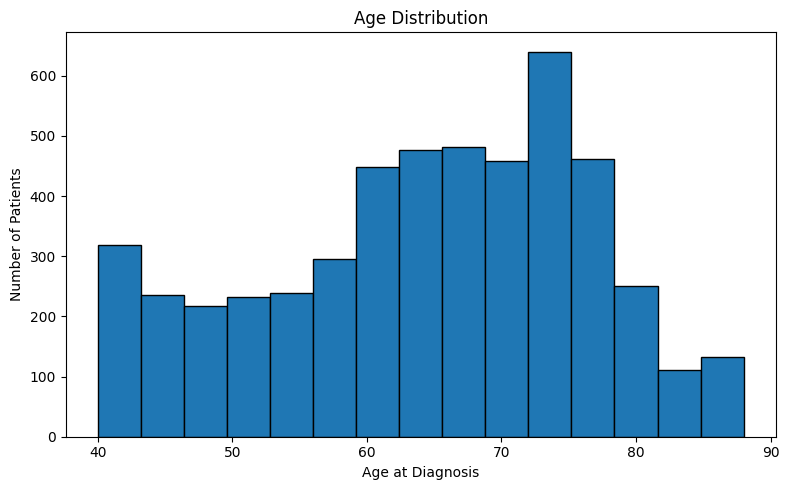

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["Age_at_Diagnosis"], bins=15, edgecolor="black")
plt.xlabel("Age at Diagnosis")
plt.ylabel("Number of Patients")
plt.title("Age Distribution")
plt.tight_layout()
plt.show()


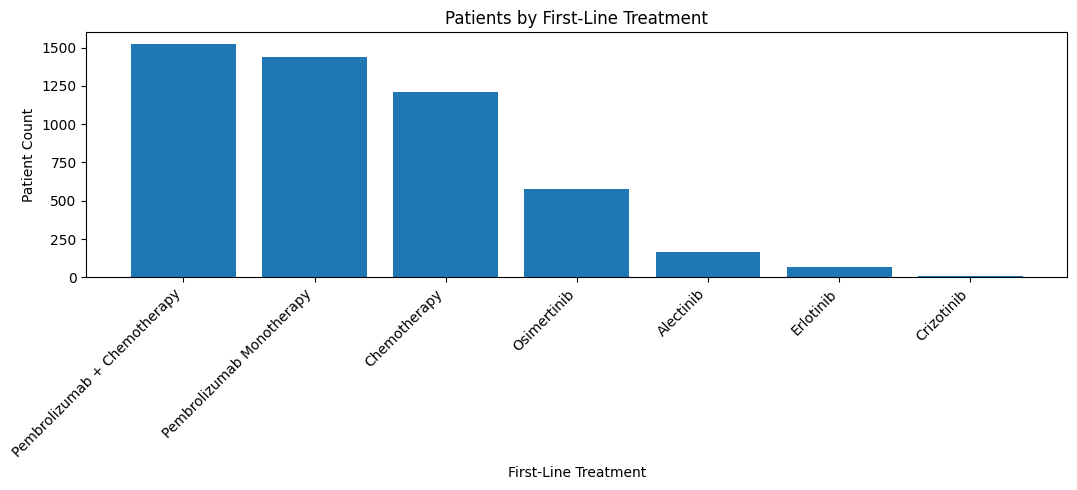

,count
First_Line_Treatment,
Pembrolizumab + Chemotherapy,1524
Pembrolizumab Monotherapy,1441
Chemotherapy,1212
Osimertinib,580
Alectinib,167
Erlotinib,67
Crizotinib,9


In [7]:
treatment_counts = df["First_Line_Treatment"].value_counts()

plt.figure(figsize=(11, 5))
plt.bar(treatment_counts.index, treatment_counts.values)
plt.xlabel("First-Line Treatment")
plt.ylabel("Patient Count")
plt.title("Patients by First-Line Treatment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(treatment_counts)


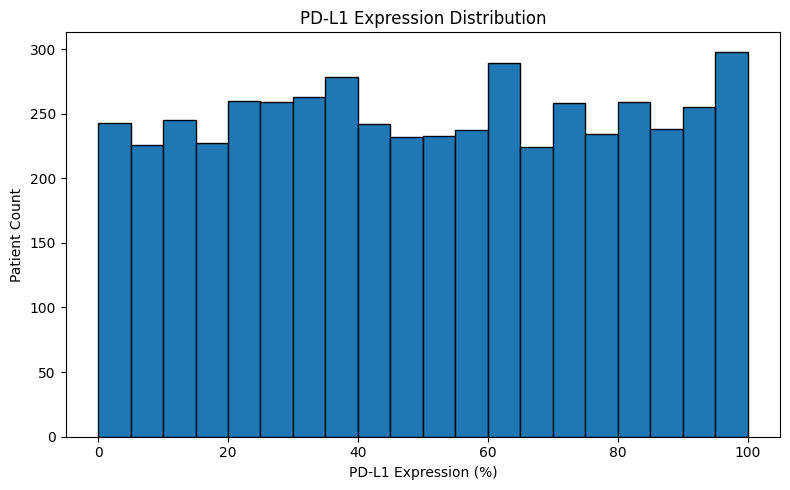

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["PDL1_Expression_Pct"], bins=20, edgecolor="black")
plt.xlabel("PD-L1 Expression (%)")
plt.ylabel("Patient Count")
plt.title("PD-L1 Expression Distribution")
plt.tight_layout()
plt.show()


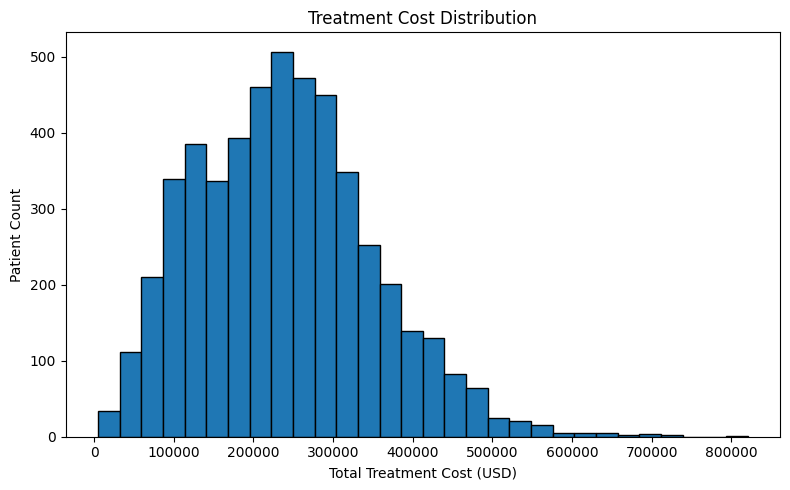

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["Total_Treatment_Cost_USD"], bins=30, edgecolor="black")
plt.xlabel("Total Treatment Cost (USD)")
plt.ylabel("Patient Count")
plt.title("Treatment Cost Distribution")
plt.tight_layout()
plt.show()


### Correlation heatmap for numerical variables


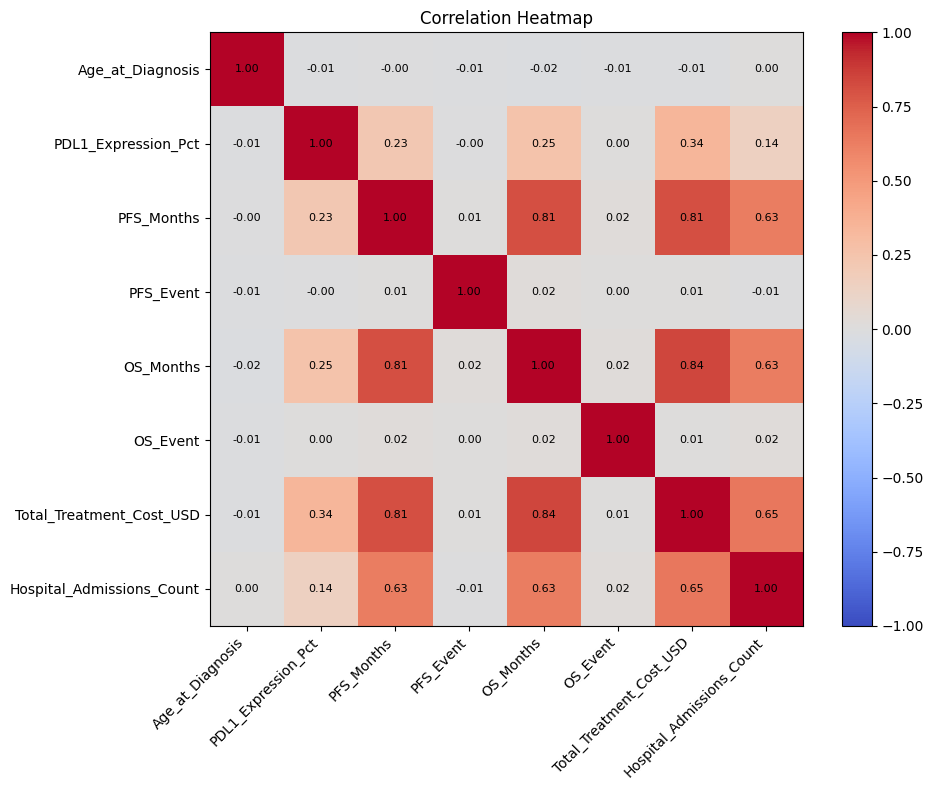

In [10]:
numeric_cols = [
    "Age_at_Diagnosis",
    "PDL1_Expression_Pct",
    "PFS_Months",
    "PFS_Event",
    "OS_Months",
    "OS_Event",
    "Total_Treatment_Cost_USD",
    "Hospital_Admissions_Count"
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 5. Patient Profile Analysis


In [11]:
df["Patient_Profile"] = (
    df["Age_Group"].astype(str) + " | " +
    df["Smoking_Status"].astype(str) + " | " +
    df["Gender"].astype(str) + " | " +
    df["EGFR_Mutation"].astype(str) + " | " +
    df["ALK_Translocation"].astype(str)
)

profile_outcomes = df.groupby("Patient_Profile").agg(
    Patient_Count=("Patient_ID", "count"),
    Average_PFS=("PFS_Months", "mean"),
    Average_OS=("OS_Months", "mean"),
    Average_Cost=("Total_Treatment_Cost_USD", "mean"),
    Average_Admissions=("Hospital_Admissions_Count", "mean")
).reset_index()

display(
    profile_outcomes.sort_values("Patient_Count", ascending=False).head(20)
)


,Patient_Profile,Patient_Count,Average_PFS,Average_OS,Average_Cost,Average_Admissions
27,60-79 | Former Smoker | Male | Negative | Nega...,823,9.482139,20.262576,215669.743621,3.850547
24,60-79 | Former Smoker | Female | Negative | Ne...,659,9.330653,20.467830,212113.455235,3.714719
9,40-59 | Former Smoker | Male | Negative | Nega...,394,9.824365,21.524873,225196.360406,3.967005
21,60-79 | Current Smoker | Male | Negative | Neg...,360,9.745000,20.623611,214790.516667,3.719444
6,40-59 | Former Smoker | Female | Negative | Ne...,313,9.602875,20.316933,216899.127796,3.897764
18,60-79 | Current Smoker | Female | Negative | N...,301,9.535880,19.899336,212600.166113,3.700997
33,60-79 | Never Smoked | Male | Negative | Negative,250,9.781200,21.083600,220646.212000,4.240000
3,40-59 | Current Smoker | Male | Negative | Neg...,197,9.406091,21.346193,212973.289340,3.634518
29,60-79 | Former Smoker | Male | Positive | Nega...,168,15.677976,32.949405,330107.690476,6.184524
30,60-79 | Never Smoked | Female | Negative | Neg...,164,9.323780,19.994512,204923.932927,3.847561


## 6. Treatment Effectiveness Analysis


In [12]:
treatment_analysis = df.groupby("First_Line_Treatment").agg(
    Patient_Count=("Patient_ID", "count"),
    Average_PFS=("PFS_Months", "mean"),
    Median_PFS=("PFS_Months", "median"),
    Average_OS=("OS_Months", "mean"),
    Median_OS=("OS_Months", "median"),
    PFS_Event_Rate=("PFS_Event", "mean"),
    OS_Event_Rate=("OS_Event", "mean")
).reset_index()

treatment_analysis["PFS_Event_Rate"] *= 100
treatment_analysis["OS_Event_Rate"] *= 100

display(treatment_analysis.sort_values("Average_PFS", ascending=False))


,First_Line_Treatment,Patient_Count,Average_PFS,Median_PFS,Average_OS,Median_OS,PFS_Event_Rate,OS_Event_Rate
0,Alectinib,167,18.167665,17.4,37.577246,37.4,85.628743,62.874251
4,Osimertinib,580,17.958448,18.3,38.475345,38.9,86.206897,67.931034
6,Pembrolizumab Monotherapy,1441,12.007078,11.9,25.981332,26.0,85.287994,65.024289
5,Pembrolizumab + Chemotherapy,1524,9.956430,10.0,21.276115,21.3,84.055118,64.829396
1,Chemotherapy,1212,5.952063,6.0,12.922277,13.0,86.138614,65.676568
3,Erlotinib,67,5.853731,5.7,12.223881,12.1,82.089552,64.179104
2,Crizotinib,9,5.522222,4.9,11.922222,13.7,100.000000,88.888889


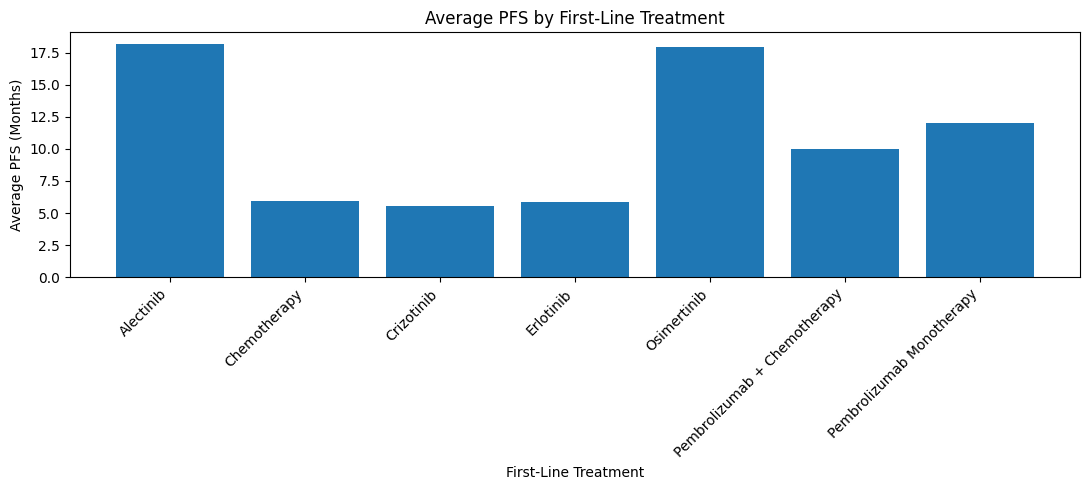

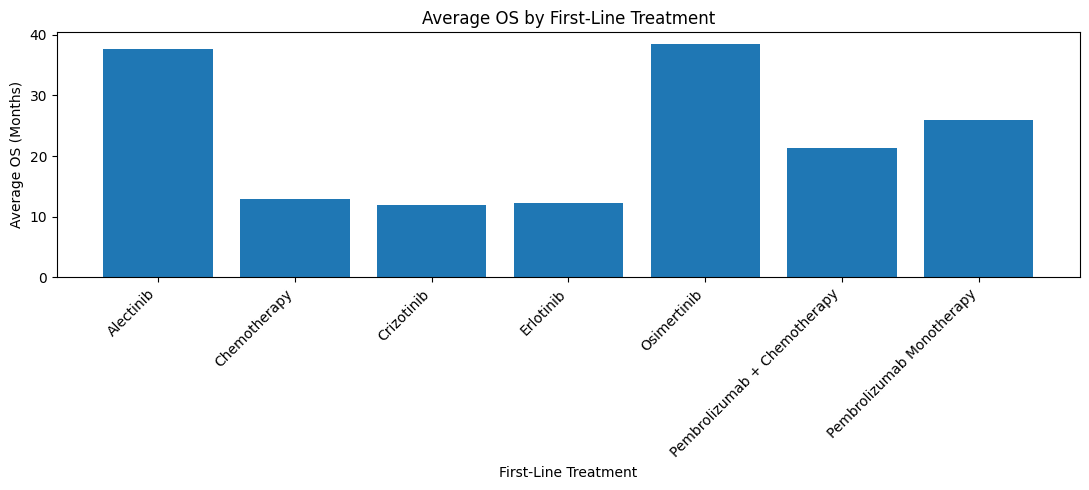

In [13]:
plt.figure(figsize=(11, 5))
plt.bar(treatment_analysis["First_Line_Treatment"], treatment_analysis["Average_PFS"])
plt.xlabel("First-Line Treatment")
plt.ylabel("Average PFS (Months)")
plt.title("Average PFS by First-Line Treatment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(treatment_analysis["First_Line_Treatment"], treatment_analysis["Average_OS"])
plt.xlabel("First-Line Treatment")
plt.ylabel("Average OS (Months)")
plt.title("Average OS by First-Line Treatment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Interpretation note:** These are descriptive comparisons from an observational/synthetic dataset. They should not be described as proof that one treatment is medically superior to another.


## 7. Survival Analysis


In [14]:
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test


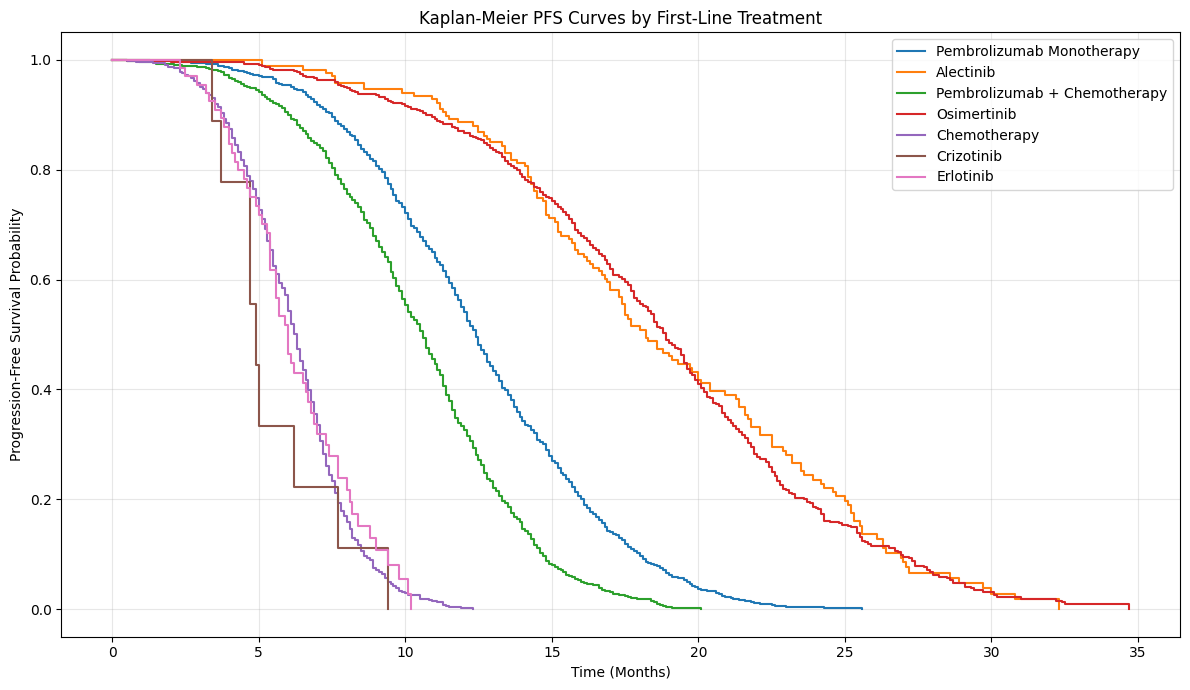

In [15]:
plt.figure(figsize=(12, 7))
kmf = KaplanMeierFitter()

for treatment in df["First_Line_Treatment"].dropna().unique():
    temp = df[df["First_Line_Treatment"] == treatment]
    kmf.fit(
        durations=temp["PFS_Months"],
        event_observed=temp["PFS_Event"],
        label=treatment
    )
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan-Meier PFS Curves by First-Line Treatment")
plt.xlabel("Time (Months)")
plt.ylabel("Progression-Free Survival Probability")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
multi_logrank = multivariate_logrank_test(
    df["PFS_Months"],
    df["First_Line_Treatment"],
    df["PFS_Event"]
)

print("Multivariate log-rank p-value:", multi_logrank.p_value)


Multivariate log-rank p-value: 0.0


## 8. Biomarker Analysis


In [17]:
egfr_analysis = df.groupby("EGFR_Mutation").agg(
    Patients=("Patient_ID", "count"),
    Average_PFS=("PFS_Months", "mean"),
    Median_PFS=("PFS_Months", "median"),
    Average_OS=("OS_Months", "mean"),
    Median_OS=("OS_Months", "median")
).reset_index()

alk_analysis = df.groupby("ALK_Translocation").agg(
    Patients=("Patient_ID", "count"),
    Average_PFS=("PFS_Months", "mean"),
    Median_PFS=("PFS_Months", "median"),
    Average_OS=("OS_Months", "mean"),
    Median_OS=("OS_Months", "median")
).reset_index()

display(egfr_analysis)
display(alk_analysis)


,EGFR_Mutation,Patients,Average_PFS,Median_PFS,Average_OS,Median_OS
0,Negative,4282,9.889374,9.5,21.243835,20.6
1,Positive,718,15.647911,16.4,33.533426,35.5


,ALK_Translocation,Patients,Average_PFS,Median_PFS,Average_OS,Median_OS
0,Negative,4802,10.490317,9.70,22.574115,21.40
1,Positive,198,16.196970,16.15,33.546465,35.35


In [18]:
# EGFR: Kaplan-Meier + log-rank
egfr_pos = df[df["EGFR_Mutation"] == "Positive"]
egfr_neg = df[df["EGFR_Mutation"] == "Negative"]

egfr_logrank = logrank_test(
    egfr_pos["PFS_Months"],
    egfr_neg["PFS_Months"],
    event_observed_A=egfr_pos["PFS_Event"],
    event_observed_B=egfr_neg["PFS_Event"]
)
print("EGFR PFS log-rank p-value:", egfr_logrank.p_value)

# ALK: Kaplan-Meier + log-rank
alk_pos = df[df["ALK_Translocation"] == "Positive"]
alk_neg = df[df["ALK_Translocation"] == "Negative"]

alk_logrank = logrank_test(
    alk_pos["PFS_Months"],
    alk_neg["PFS_Months"],
    event_observed_A=alk_pos["PFS_Event"],
    event_observed_B=alk_neg["PFS_Event"]
)
print("ALK PFS log-rank p-value:", alk_logrank.p_value)


EGFR PFS log-rank p-value: 2.5931235393422404e-116
ALK PFS log-rank p-value: 3.1457225377886195e-26


In [19]:
df["PDL1_Group"] = pd.cut(
    df["PDL1_Expression_Pct"],
    bins=[-1, 0, 1, 49, 100],
    labels=["0%", "1%", "2-49%", "50-100%"]
)

pdl1_analysis = df.groupby("PDL1_Group", observed=True).agg(
    Patients=("Patient_ID", "count"),
    Average_PFS=("PFS_Months", "mean"),
    Median_PFS=("PFS_Months", "median"),
    Average_OS=("OS_Months", "mean"),
    Median_OS=("OS_Months", "median")
).reset_index()

display(pdl1_analysis)


,PDL1_Group,Patients,Average_PFS,Median_PFS,Average_OS,Median_OS
0,0%,45,10.102222,7.60,20.053333,16.70
1,1%,52,10.832692,9.55,23.038462,21.55
2,2-49%,2378,9.250841,7.70,19.839613,17.05
3,50-100%,2525,12.104990,11.70,26.045188,25.10


## 9. Cox Proportional Hazards Model


In [20]:
cox_data = df[
    [
        "PFS_Months",
        "PFS_Event",
        "Age_at_Diagnosis",
        "PDL1_Expression_Pct",
        "EGFR_Mutation",
        "ALK_Translocation"
    ]
].copy()

cox_data = pd.get_dummies(
    cox_data,
    columns=["EGFR_Mutation", "ALK_Translocation"],
    drop_first=True,
    dtype=int
)

cph = CoxPHFitter()
cph.fit(
    cox_data,
    duration_col="PFS_Months",
    event_col="PFS_Event"
)

cph.print_summary()


<lifelines.CoxPHFitter: fitted with 5000 total observations, 739 right-censored observations>
             duration col = 'PFS_Months'
                event col = 'PFS_Event'
      baseline estimation = breslow
   number of observations = 5000
number of events observed = 4261
   partial log-likelihood = -31367.99
         time fit was run = 2026-09-21 22:11:33 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
Age_at_Diagnosis           -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
PDL1_Expression_Pct        -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
EGFR_Mutation_Positive     -1.48      0.23      0.05           -1.59           -1.38                0.20                0.25
ALK_Translocation_Positive -1.53      0.22      0.08           -1.69           -1.36                0.18                0.26

                            cmp to      z      p  -log2(p)
covariate                                                 
Age_at_Diagnosis              0.00  -0.17   0.87      0.20
PDL1_Expression_Pct           0.00 -18.58 <0.005    253.66
EGFR_Mutation_Positive        0.00 -28.42 <0.005    587.58
ALK_Translocation_Positive    0.00 -18.22 <0.005    243.96
---
Concordance = 0.66
Partial AIC = 62743.98
log-likelihood ratio test = 1326.42 on 4 df
-log2(p) of ll-ratio test = 947.43

Optional assumption check (can print a long report):

```python
cph.check_assumptions(cox_data, p_value_threshold=0.05)
```


## 10. Machine Learning — Treatment Cost Prediction


### Deployment model
For the web interface, we use only variables that can reasonably be known at or near treatment start:

- Age
- Gender
- Smoking status
- EGFR
- ALK
- PD-L1
- First-line treatment

We intentionally avoid PFS, OS and future hospital admissions in the deployed model because those are follow-up variables.


In [21]:
baseline_features = [
    "Age_at_Diagnosis",
    "Gender",
    "Smoking_Status",
    "EGFR_Mutation",
    "ALK_Translocation",
    "PDL1_Expression_Pct",
    "First_Line_Treatment"
]

target = "Total_Treatment_Cost_USD"

X = df[baseline_features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

categorical_features = [
    "Gender",
    "Smoking_Status",
    "EGFR_Mutation",
    "ALK_Translocation",
    "First_Line_Treatment"
]

numeric_features = [
    "Age_at_Diagnosis",
    "PDL1_Expression_Pct"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)


In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=250,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

results = []
trained_pipelines = {}

for name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    cv_r2 = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="r2"
    ).mean()

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "Test_R2": r2,
        "CV_R2": cv_r2
    })

    trained_pipelines[name] = pipeline

results_df = pd.DataFrame(results).sort_values("Test_R2", ascending=False)
display(results_df)


,Model,MAE,RMSE,Test_R2,CV_R2
0,Linear Regression,46402.510811,62360.050113,0.673502,0.651980
2,Gradient Boosting,46698.775631,62976.212637,0.667018,0.647767
1,Random Forest,52120.452489,69576.436749,0.593565,0.567796


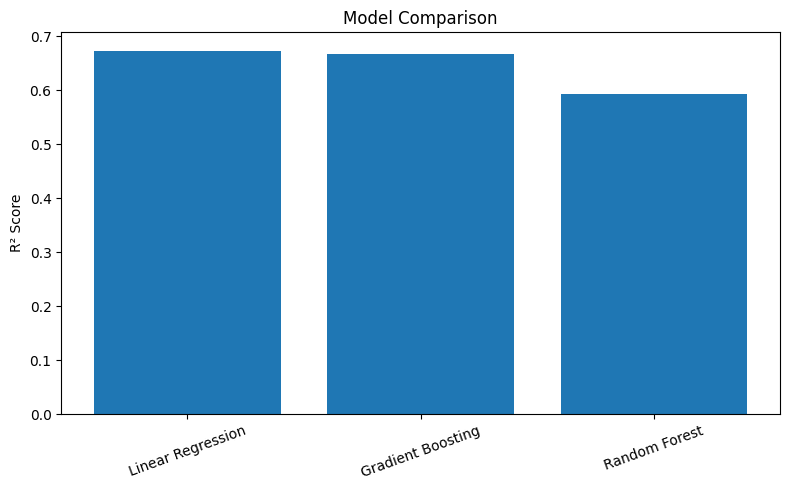

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Test_R2"])
plt.ylabel("R² Score")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [24]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

best_predictions = best_pipeline.predict(X_test)

print("Selected model:", best_model_name)
print("MAE:", mean_absolute_error(y_test, best_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_predictions)))
print("R²:", r2_score(y_test, best_predictions))


Selected model: Linear Regression
MAE: 46402.510810670836
RMSE: 62360.05011294642
R²: 0.6735024054834857


### Actual vs Predicted Cost


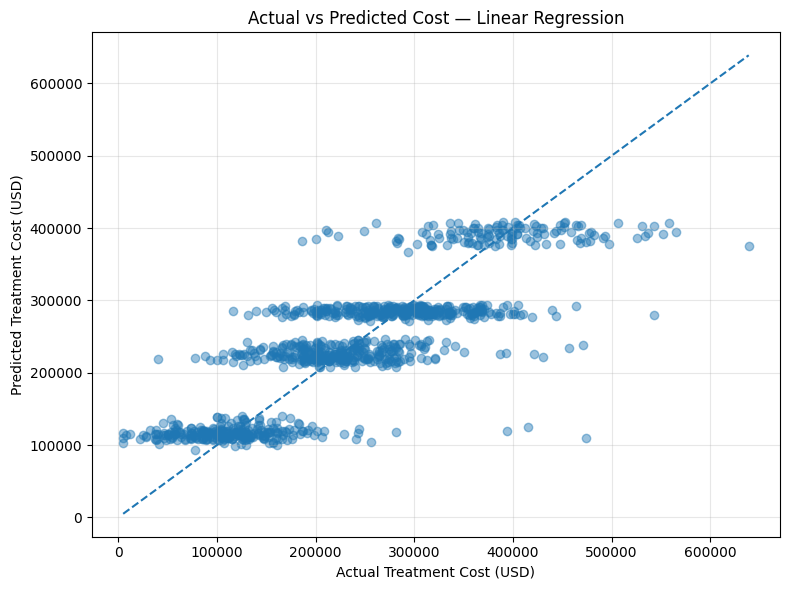

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_predictions, alpha=0.45)
low = min(y_test.min(), best_predictions.min())
high = max(y_test.max(), best_predictions.max())
plt.plot([low, high], [low, high], linestyle="--")
plt.xlabel("Actual Treatment Cost (USD)")
plt.ylabel("Predicted Treatment Cost (USD)")
plt.title(f"Actual vs Predicted Cost — {best_model_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Residual Plot


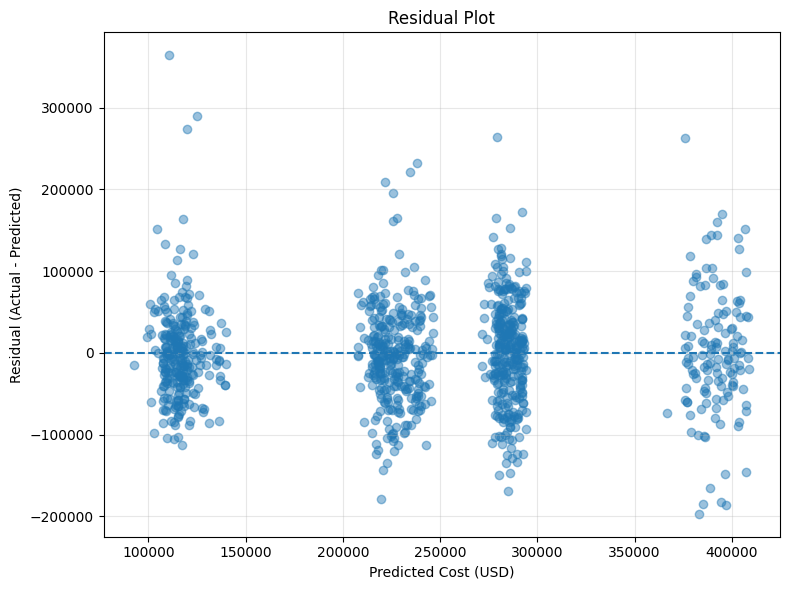

In [26]:
residuals = y_test.to_numpy() - best_predictions

plt.figure(figsize=(8, 6))
plt.scatter(best_predictions, residuals, alpha=0.45)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Cost (USD)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Permutation Feature Importance


,Feature,Importance
6,First_Line_Treatment,1.189052
5,PDL1_Expression_Pct,0.016242
3,EGFR_Mutation,0.001064
0,Age_at_Diagnosis,-0.000001
1,Gender,-0.000017
4,ALK_Translocation,-0.000018
2,Smoking_Status,-0.000268


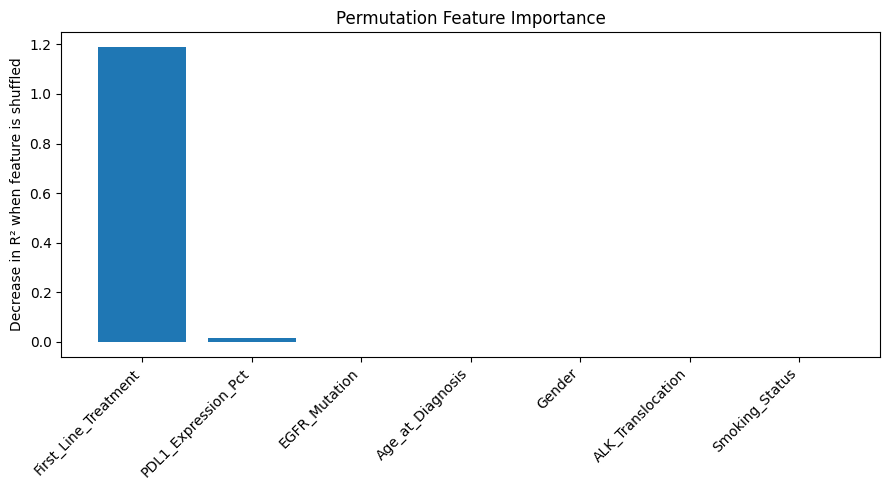

In [27]:
perm = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="r2"
)

importance_df = pd.DataFrame({
    "Feature": baseline_features,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

display(importance_df)

plt.figure(figsize=(9, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.ylabel("Decrease in R² when feature is shuffled")
plt.title("Permutation Feature Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 11. Save the trained model


In [28]:
MODEL_FILE = "best_cost_model.joblib"
joblib.dump(best_pipeline, MODEL_FILE)

print("Saved model:", MODEL_FILE)
print("Model type:", best_model_name)


Saved model: best_cost_model.joblib
Model type: Linear Regression


## 12. Web Interface with Gradio


In [34]:
import gradio as gr

treatment_options = sorted(df["First_Line_Treatment"].dropna().unique().tolist())

def predict_treatment_cost(
    age,
    gender,
    smoking_status,
    egfr_status,
    alk_status,
    pdl1_expression,
    first_line_treatment
):
    try:
        input_df = pd.DataFrame([{ # Wrapped dictionary in a list to create a single-row DataFrame
            "Age_at_Diagnosis": int(age),
            "Gender": gender,
            "Smoking_Status": smoking_status,
            "EGFR_Mutation": egfr_status,
            "ALK_Translocation": alk_status,
            "PDL1_Expression_Pct": float(pdl1_expression),
            "First_Line_Treatment": first_line_treatment
        }])

        prediction = float(best_pipeline.predict(input_df)[0])

        return (
            f"Estimated Treatment Cost: {prediction:,.0f}\n\n"
            f"Model: {best_model_name}\n"
        )
    except Exception as e:
        return f"An error occurred during prediction: {e}"

demo = gr.Interface(
    fn=predict_treatment_cost,
    inputs=[
        gr.Slider(40, 90, value=65, step=1, label="Age at Diagnosis"),
        gr.Dropdown(["Male", "Female"], value="Male", label="Gender"),
        gr.Dropdown(
            ["Former Smoker", "Current Smoker", "Never Smoked"],
            value="Former Smoker",
            label="Smoking Status"
        ),
        gr.Dropdown(["Negative", "Positive"], value="Negative", label="EGFR Mutation"),
        gr.Dropdown(["Negative", "Positive"], value="Negative", label="ALK Translocation"),
        gr.Slider(0, 100, value=50, step=1, label="PDL1_Expression_Pct (%)"),
        gr.Dropdown(
            treatment_options,
            value=treatment_options[0],
            label="First-Line Treatment"
        )
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Cancer Treatment Analytics & Cost Prediction System",
    description=(
        "This is a demo for the Cancer Treatment Analytics & Cost Prediction System."

    ),
    flagging_mode="never"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0a60a5054268877162.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 13. Conclusion

This project demonstrates an end-to-end oncology analytics workflow:

1. Data quality assessment and EDA.
2. Patient and treatment profiling.
3. PFS and OS survival analysis.
4. Biomarker analysis.
5. Cox proportional-hazards modeling.
6. Machine-learning model comparison.
7. Treatment-cost prediction.
8. Web-based user interface.

### Limitation
The included CSV is a **reconstructed synthetic dataset**, not the exact lost original dataset and not real clinical patient data.
